In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np

In [10]:
#Load all files from 1st set

data_path = r"E:\Alok\Job_Prep\Projects_and_Codes\nasa_archive\1st_test\1st_test"
files = sorted(os.listdir(data_path))
print(f"Total snapshots: {len(files)}")

Total snapshots: 2156


In [11]:
df=pd.read_csv(os.path.join(data_path, files[0]))
df.head()

,-0.022\t-0.039\t-0.183\t-0.054\t-0.105\t-0.134\t-0.129\t-0.142
0,-0.105\t-0.017\t-0.164\t-0.183\t-0.049\t0.029\...
1,-0.183\t-0.098\t-0.195\t-0.125\t-0.005\t-0.007...
2,-0.178\t-0.161\t-0.159\t-0.178\t-0.100\t-0.115...
3,-0.208\t-0.129\t-0.261\t-0.098\t-0.151\t-0.205...
4,-0.232\t-0.061\t-0.281\t-0.125\t0.046\t-0.088\...


In [12]:
#add column names to the dataframe
columns = ['b1_ch1', 'b1_ch2', 'b2_ch1', 'b2_ch2', 'b3_ch1', 'b3_ch2', 'b4_ch1', 'b4_ch2']

In [13]:
df_first = pd.read_csv(os.path.join(data_path, files[0]), sep='\t', header=None, names=columns)
df_last = pd.read_csv(os.path.join(data_path, files[-1]), sep='\t', header=None, names=columns)

df_first.head(), df_last.head()

(   b1_ch1  b1_ch2  b2_ch1  b2_ch2  b3_ch1  b3_ch2  b4_ch1  b4_ch2
 0  -0.022  -0.039  -0.183  -0.054  -0.105  -0.134  -0.129  -0.142
 1  -0.105  -0.017  -0.164  -0.183  -0.049   0.029  -0.115  -0.122
 2  -0.183  -0.098  -0.195  -0.125  -0.005  -0.007  -0.171  -0.071
 3  -0.178  -0.161  -0.159  -0.178  -0.100  -0.115  -0.112  -0.078
 4  -0.208  -0.129  -0.261  -0.098  -0.151  -0.205  -0.063  -0.066,
    b1_ch1  b1_ch2  b2_ch1  b2_ch2  b3_ch1  b3_ch2  b4_ch1  b4_ch2
 0  -0.071  -0.117  -0.295  -0.471   0.132  -0.144  -0.173  -0.020
 1  -0.066  -0.068  -0.063  -0.417  -0.271  -0.107  -0.078  -0.081
 2  -0.078  -0.154  -0.193  -0.122  -0.254  -0.154   0.034  -0.107
 3  -0.146  -0.222  -0.320   0.037   0.205  -0.349   0.090  -0.093
 4  -0.083  -0.330  -0.088  -0.176  -0.417   0.103  -0.061  -0.190)

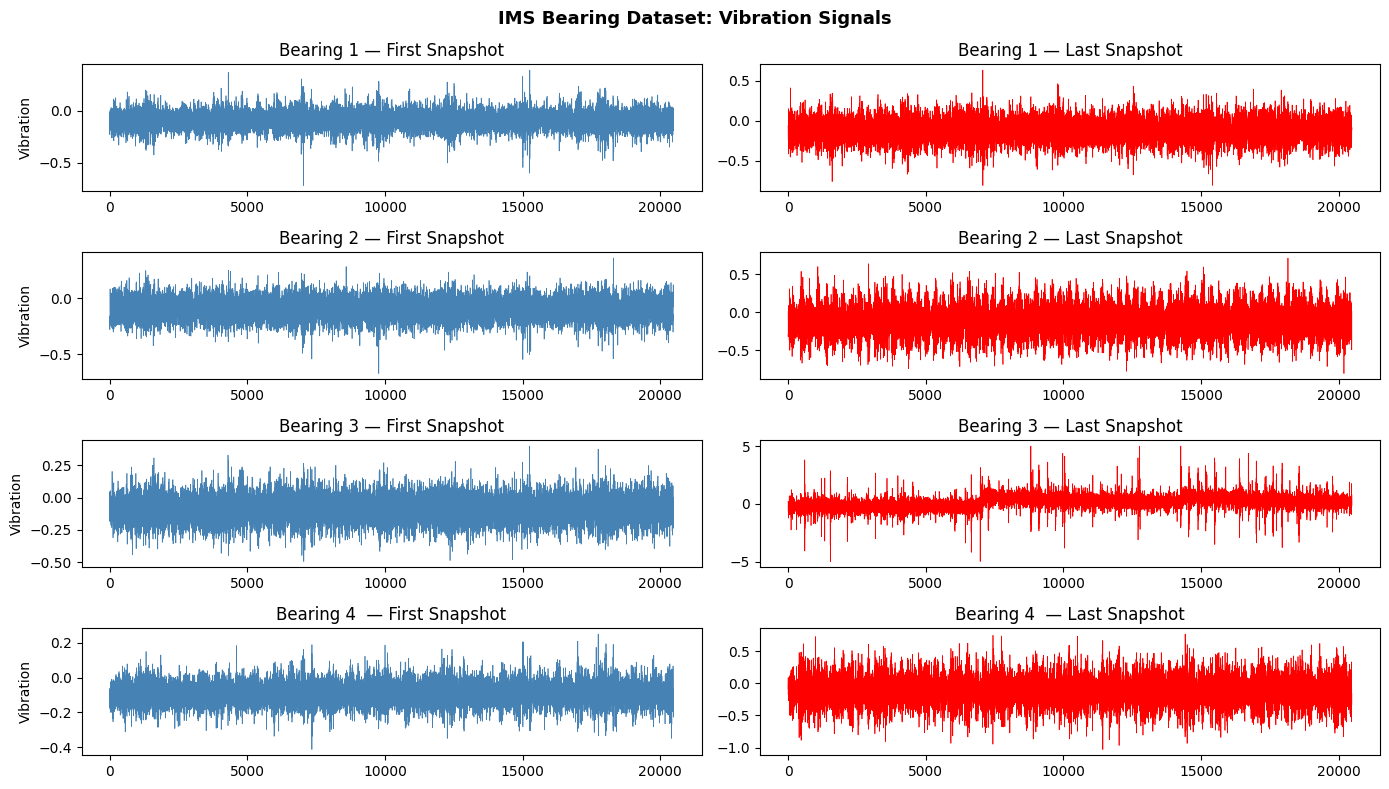

In [14]:
fig, axes = plt.subplots(4, 2, figsize=(14, 8))

bearings = [
    ('b1_ch1', 'Bearing 1'),
    ('b2_ch1', 'Bearing 2'),
    ('b3_ch1', 'Bearing 3'),
    ('b4_ch1', 'Bearing 4 '),]

for i, (col, title) in enumerate(bearings):

    axes[i, 0].plot(df_first[col], color='steelblue', linewidth=0.5)
    axes[i, 0].set_title(f'{title} — First Snapshot')
    axes[i, 0].set_ylabel('Vibration')
    
    axes[i, 1].plot(df_last[col], color='red', linewidth=0.5)
    axes[i, 1].set_title(f'{title} — Last Snapshot')
    
plt.suptitle('IMS Bearing Dataset: Vibration Signals', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/first_vs_last.png', dpi=150, bbox_inches='tight')
plt.show()

Bearing 3 shows dramatic change - 10x amplitude increase  
Bearing 4 shows gradual degradation  
Bearing 1 and 2 shows very minimal change  
ML Goal: detect Bearing 3 and 4 degradation automatically  

In [15]:
#Load all files from 2nd set
data_path = r"E:\Alok\Job_Prep\Projects_and_Codes\nasa_archive\2nd_test\2nd_test"
second_test_files = sorted(os.listdir(data_path))

print(f"Total snapshots: {len(second_test_files)}")

Total snapshots: 984


In [16]:
#creating a function to build rms dataframe
columns= ['b1_ch1', 'b2_ch1', 'b3_ch1', 'b4_ch1']
def build_rms_dataframe(data_path,files,columns):
    rms_records = []
    
    for file in files:
        df = pd.read_csv(os.path.join(data_path, file), sep='\t', header=None, names=columns)
        rms_values = np.sqrt((df**2).mean())
        rms_values['timestamp'] = file
        rms_records.append(rms_values)
        
    rms_df= pd.DataFrame(rms_records)
    rms_df.set_index('timestamp', inplace=True)
    return rms_df

In [17]:
rms_df = build_rms_dataframe(data_path, second_test_files, columns)

In [18]:
rms_df.head(),rms_df.shape

(                       b1_ch1    b2_ch1    b3_ch1    b4_ch1
 timestamp                                                  
 2004.02.12.10.32.39  0.074179  0.090944  0.109404  0.054103
 2004.02.12.10.42.39  0.075382  0.093419  0.109817  0.056101
 2004.02.12.10.52.39  0.076230  0.093718  0.109861  0.056145
 2004.02.12.11.02.39  0.078724  0.092947  0.110667  0.056807
 2004.02.12.11.12.39  0.078474  0.095348  0.107506  0.056841,
 (984, 4))

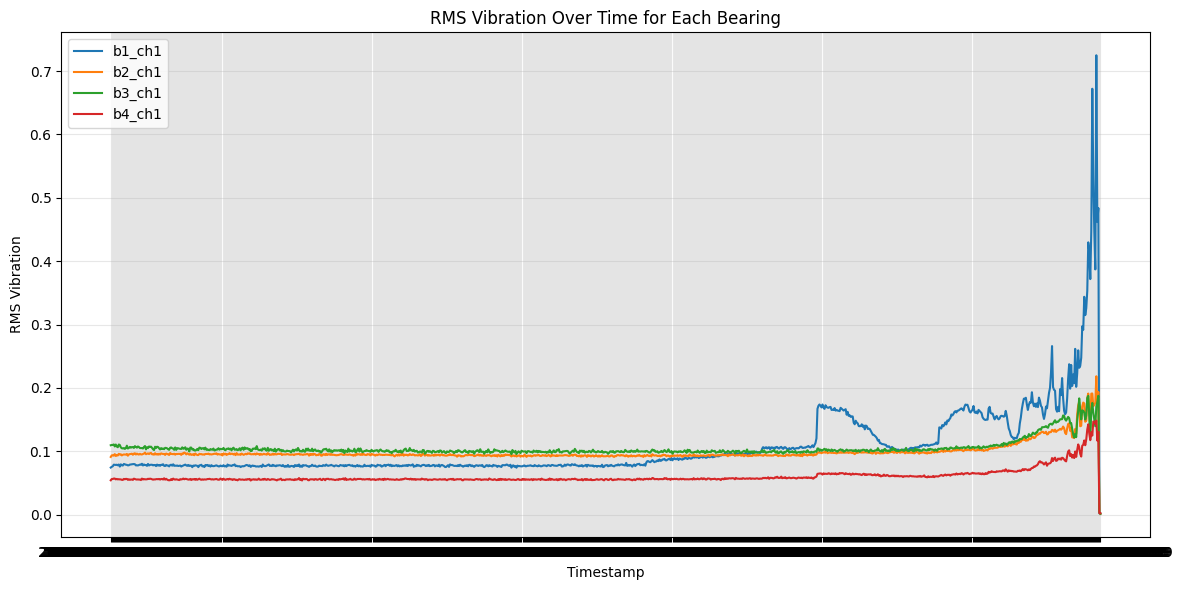

In [19]:
#plotting the RMS values for each bearing over time
plt.figure(figsize=(12, 6))
for col in columns:
    plt.plot(rms_df.index, rms_df[col], label=col)
plt.xlabel('Timestamp')
plt.ylabel('RMS Vibration')
plt.title('RMS Vibration Over Time for Each Bearing')
#plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()
plt.savefig('../results/rms_over_time.png', dpi=150)

# Add grid for readability
plt.grid(True, alpha=0.3)

plt.show()


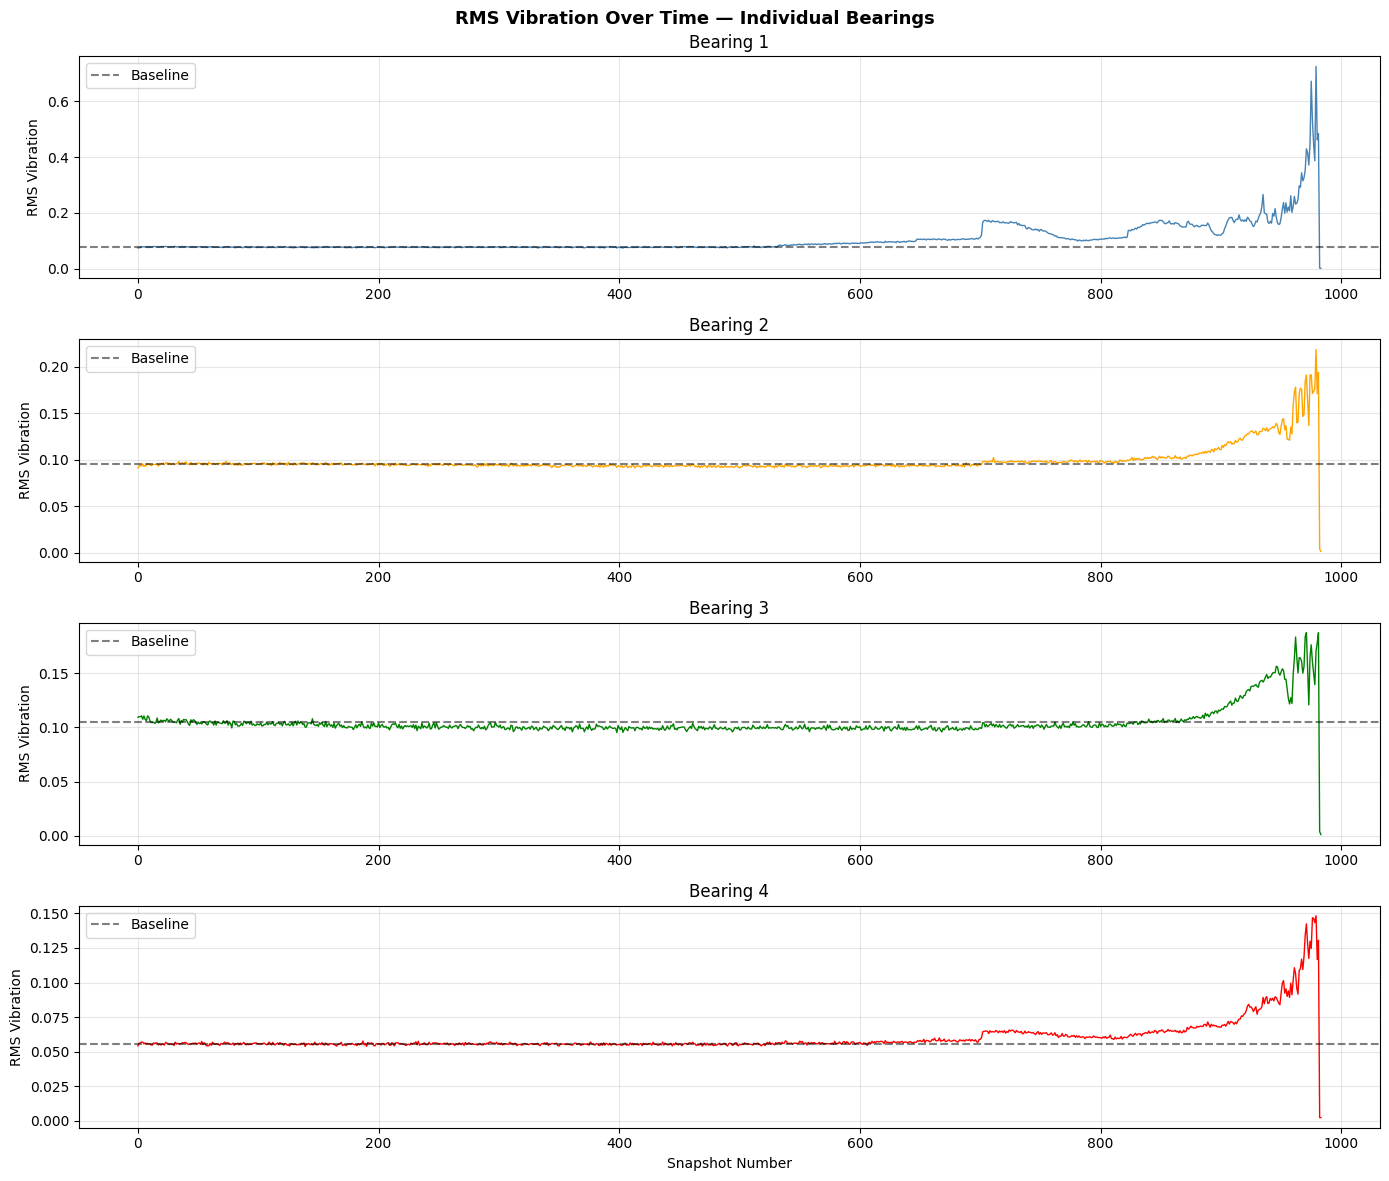

In [20]:
fig, axes = plt.subplots(4, 1, figsize=(14, 12))

bearing_labels = {
    'b1_ch1': 'Bearing 1',
    'b2_ch1': 'Bearing 2', 
    'b3_ch1': 'Bearing 3',
    'b4_ch1': 'Bearing 4',
}

colors = ['steelblue', 'orange', 'green', 'red']

for i, (col, color) in enumerate(zip(columns, colors)):
    axes[i].plot(rms_df[col].values, color=color, linewidth=1)
    axes[i].set_title(bearing_labels[col])
    axes[i].set_ylabel('RMS Vibration')
    axes[i].grid(True, alpha=0.3)
    
    # Add horizontal baseline reference line
    baseline = rms_df[col].iloc[:100].mean()
    axes[i].axhline(y=baseline, color='black', 
                    linestyle='--', alpha=0.5, label='Baseline')
    axes[i].legend()

axes[-1].set_xlabel('Snapshot Number')
plt.suptitle('RMS Vibration Over Time — Individual Bearings', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/rms_individual_bearings.png', dpi=150)
plt.show()

Key Insights From the Plot:  
1. Bearing 1 is the primary failure  
RMS stays flat at 0.08 for most of the test  
Around snapshot 800 it starts rising  
Spikes dramatically to 0.72 at the end — 9x normal  
This is catastrophic failure  

2. Early warning signal visible  
Bearing 1 starts rising around snapshot 750-800  
That's your early detection window — before catastrophic failure  
Your ML model next week needs to catch this early rise  

3. Bearing 4 drops to 0 at the end  
Interesting — RMS hits 0 at the very last snapshot  
This could mean the sensor disconnected at failure  
Or bearing completely seized — no vibration = no movement  

4. Bearings 2 and 3 relatively stable
Minor increase at the very end  
Likely sympathy vibration from Bearing 1 failure nearby  